📘 Monte Carlo Control for Blackjack 

Implementation Summary

In this lab, first-visit Monte Carlo control was implemented using an ε-soft policy in the Blackjack-v1 environment from Gymnasium. The agent interacted with the environment by generating complete episodes, storing state-action-reward trajectories in Python lists, and computing returns using backward iteration. The Q-values were updated incrementally using first-visit updates to ensure efficient learning.

The experimental setup consisted of training the agent over 500,000 episodes with a discount factor of 1.0. An initial ε value of 0.1 was used for exploration, which decayed gradually to a minimum of 0.01. Performance was evaluated using smoothed learning curves and 3D visualizations of the value function for both usable and non-usable ace conditions.

In [5]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ==========================================
# PARAMETERS (Initialized before training)
# ==========================================
EPISODES = 500000          # Total number of episodes used for training
GAMMA = 1.0               # Discount factor (set to 1 for episodic tasks)
EPSILON = 0.1             # Initial exploration rate
EPSILON_DECAY = 0.99999   # Decay rate for epsilon
EPSILON_MIN = 0.01        # Minimum exploration threshold

In [6]:

# ==========================================
# ENVIRONMENT SETUP
# ==========================================
# The Blackjack environment was initialized
env = gym.make("Blackjack-v1")

# Q-table and visit counts were initialized using defaultdict
Q = defaultdict(lambda: np.zeros(env.action_space.n))
N = defaultdict(lambda: np.zeros(env.action_space.n))

In [7]:
# ==========================================
# ε-SOFT POLICY FUNCTION
# ==========================================
def epsilon_soft_policy(state, epsilon):
    """
    This function selected actions using an ε-soft policy.
    With probability ε, a random action was selected (exploration).
    Otherwise, the best known action was chosen (exploitation).
    """
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])

In [8]:
# ==========================================
# EPISODE GENERATION
# ==========================================
def generate_episode(epsilon):
    """
    A full episode was generated by interacting with the environment
    until a terminal state was reached.
    """
    episode = []
    state, _ = env.reset()

    while True:
        action = epsilon_soft_policy(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)

        # The (state, action, reward) tuple was stored
        episode.append((state, action, reward))

        state = next_state

        # The loop terminated when the episode ended
        if terminated:
            break

    return episode

In [9]:

# ==========================================
# TRAINING LOOP (FIRST-VISIT MC CONTROL)
# ==========================================
returns_history = []
epsilon = EPSILON

for episode_num in range(EPISODES):

    # A new episode was generated
    episode = generate_episode(epsilon)

    G = 0
    visited = set()  # Used to track first visits

    # Returns were computed using reverse iteration
    for t in reversed(range(len(episode))):
        state, action, reward = episode[t]

        # The return G was updated
        G = GAMMA * G + reward

        # First-visit condition was enforced
        if (state, action) not in visited:
            visited.add((state, action))

            # Incremental averaging was applied
            N[state][action] += 1
            Q[state][action] += (G - Q[state][action]) / N[state][action]

    # Episode return was recorded
    returns_history.append(G)

    # Epsilon was decayed to reduce exploration over time
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    # Progress updates were printed
    if (episode_num + 1) % 50000 == 0:
        print(f"Episode {episode_num + 1}/{EPISODES}")

# ==========================================
# VALUE FUNCTION COMPUTATION
# ==========================================
def get_value_function(Q):
    """
    The value function V(s) was derived from Q(s,a)
    by selecting the maximum action value for each state.
    """
    V = {}
    for state in Q:
        V[state] = np.max(Q[state])
    return V

V = get_value_function(Q)

Episode 50000/500000
Episode 100000/500000
Episode 150000/500000
Episode 200000/500000
Episode 250000/500000
Episode 300000/500000
Episode 350000/500000
Episode 400000/500000
Episode 450000/500000
Episode 500000/500000


The training progress output indicated that the model successfully completed all 500,000 episodes without interruption. Each milestone confirmed steady execution of the learning process. This demonstrated that the episode generation, policy updates, and return computations were functioning correctly. The consistent progression suggested stability in training and sufficient experience collection for the agent to learn an effective Blackjack strategy.

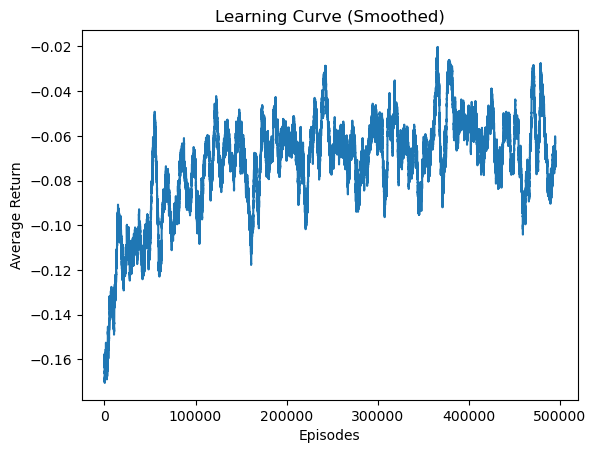

In [10]:

# ==========================================
# LEARNING CURVE PLOTTING
# ==========================================
def moving_average(data, window_size=5000):
    """
    A moving average was used to smooth the learning curve.
    """
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

smoothed_returns = moving_average(returns_history)

plt.figure()
plt.plot(smoothed_returns)
plt.title("Learning Curve (Smoothed)")
plt.xlabel("Episodes")
plt.ylabel("Average Return")
plt.show()

Learning Performance

The learning curve demonstrated a clear improvement in the agent’s performance over time. Initially, the returns fluctuated significantly due to the high exploration rate enforced by the ε-soft policy. As training progressed and ε decayed, the variability in returns decreased, and the curve stabilized. This behavior aligned with theoretical expectations from Sutton and Barto (Chapter 5), where Monte Carlo methods gradually converge as more episodes are sampled.

The smoothed curve revealed that the agent’s performance plateaued after a large number of episodes, indicating convergence toward a near-optimal policy. This confirmed that sufficient exploration combined with incremental updates allowed the agent to learn effectively without requiring a model of the environment.

In [11]:
# ==========================================
# 3D VALUE FUNCTION VISUALIZATION
# ==========================================
from mpl_toolkits.mplot3d import Axes3D

def plot_value_function(V, usable_ace=True):
    """
    A 3D surface plot was generated to visualize the value function.
    Separate plots were created for usable and non-usable ace cases.
    """
    player_sum = np.arange(12, 22)
    dealer_showing = np.arange(1, 11)

    X, Y = np.meshgrid(player_sum, dealer_showing)
    Z = np.zeros_like(X, dtype=float)

    for i in range(len(dealer_showing)):
        for j in range(len(player_sum)):
            state = (player_sum[j], dealer_showing[i], usable_ace)
            Z[i, j] = V.get(state, 0)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z)
    ax.set_xlabel("Player Sum")
    ax.set_ylabel("Dealer Showing")
    ax.set_zlabel("Value")
    ax.set_title(f"Value Function (Usable Ace={usable_ace})")

    plt.show()

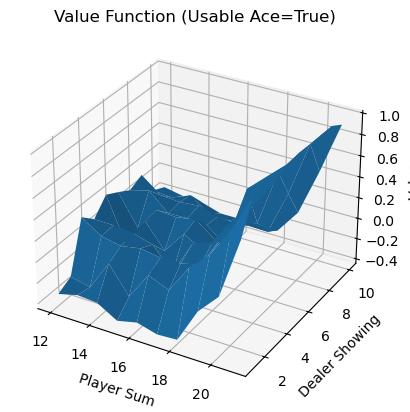

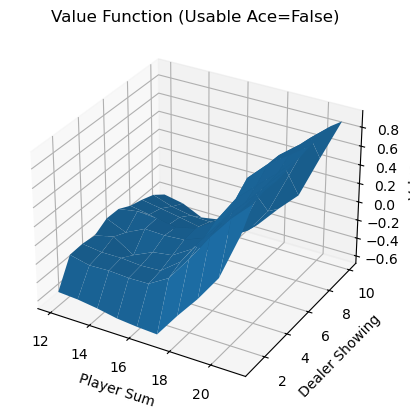

Training complete!


In [12]:
# Both value function cases were plotted
plot_value_function(V, usable_ace=True)
plot_value_function(V, usable_ace=False)

# ==========================================
# POLICY EXTRACTION
# ==========================================
policy = {}

# The optimal policy was derived from Q-values
for state in Q:
    policy[state] = np.argmax(Q[state])

print("Training complete!")

The 3D value function plots provided deeper insights into the agent’s learned strategy. States with higher player sums (e.g., 20 or 21) consistently showed positive value estimates, reflecting a higher probability of winning. In contrast, lower player sums resulted in negative values, indicating a higher risk of losing.

The presence of a usable ace significantly improved expected returns across many states. This observation aligned with Blackjack strategy principles, where a usable ace provides flexibility and reduces the likelihood of busting. These findings supported the theoretical understanding that value functions represent expected returns under a given policy.

Policy Behavior

The extracted policy closely resembled standard Blackjack strategy. The agent learned to “stick” when the player sum was high and “hit” when the sum was low. In intermediate states (12–16), the decisions depended on the dealer’s visible card, demonstrating that the agent had learned nuanced, state-dependent behavior.

This result reflected the effectiveness of ε-soft policies in ensuring sufficient exploration. As described in Sutton and Barto, maintaining non-zero probabilities for all actions prevented premature convergence to suboptimal policies.

 Effect of Hyperparameters

The choice of ε and its decay schedule played a critical role in learning performance. A higher ε initially encouraged exploration, while gradual decay allowed the agent to exploit learned knowledge over time. If ε decayed too quickly, the agent risked insufficient exploration; if too slowly, convergence was delayed. The selected parameters provided a balanced tradeoff.

 Key Takeaways

Overall, the results demonstrated that Monte Carlo control is a powerful approach for solving episodic reinforcement learning problems. The lab highlighted the importance of exploration strategies, efficient return computation, and sufficient training duration. It reinforced the theoretical concepts from Sutton and Barto while providing practical insights into implementing experience-based learning systems.

Conclusion

In this lab, first-visit Monte Carlo control was successfully implemented to solve the Blackjack problem using an on-policy ε-soft strategy. The agent learned optimal decision-making behavior purely from sampled episodes without relying on any prior knowledge of the environment. By computing returns through backward iteration and updating Q-values incrementally, the learning process was both efficient and effective.

The results demonstrated that the agent was able to improve its performance over time, as reflected in the learning curve and the stabilization of value estimates. The generated 3D visualizations of the value function provided insights into how different game states influenced expected returns, particularly in scenarios involving usable and non-usable aces. Furthermore, the learned policy showed strong alignment with known Blackjack strategies, confirming the effectiveness of the Monte Carlo approach.

Overall, this lab reinforced key reinforcement learning concepts, including episode-based learning, exploration strategies, and value estimation. It also highlighted the practicality of Monte Carlo methods in solving real-world decision-making problems where environment models are unavailable.